In [1]:
%load_ext autoreload
%autoreload 2
%autosave 30

Autosaving every 30 seconds


# Plot Scores
In this notebook we will investigate the scores of the models across different leadtimes

In [2]:
import json

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

import wandb
from genpp.plots import RESULTS_DIR

In [3]:
api = wandb.Api()

# Get runs with a specific tag
runs = api.runs(
    "feik/genpp",  # Replace with your entity/project
    filters={"tags": {"$all": ["final", "wb2"], "$nin": ["deprecated", "extra"]}},
)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/feik/.netrc.


In [4]:
for run in runs:
    print(run.tags, run.url)

['baseline', 'best', 'final', 'wb2'] https://wandb.ai/feik/genpp/runs/utgo5npv
['drn', 'final', 'wb2'] https://wandb.ai/feik/genpp/runs/m5y9kwlh
['es', 'final', 'indirect', 'lngm', 'wb2'] https://wandb.ai/feik/genpp/runs/057uzdg4
['final', 'indirect', 'lngm', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/4g2v39ob
['final', 'indirect', 'lngm', 'mses', 'wb2'] https://wandb.ai/feik/genpp/runs/1wmdbxm1
['direct', 'es', 'final', 'lngm', 'wb2'] https://wandb.ai/feik/genpp/runs/unt6oe9w
['direct', 'final', 'lngm', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/y2to8vmf
['direct', 'final', 'lngm', 'mses', 'wb2'] https://wandb.ai/feik/genpp/runs/hrf26g7y
['engression', 'es', 'final', 'indirect', 'wb2'] https://wandb.ai/feik/genpp/runs/3j5g7ils
['engression', 'final', 'indirect', 'pes', 'wb2'] https://wandb.ai/feik/genpp/runs/2ajwxmir
['engression', 'final', 'indirect', 'mses', 'wb2'] https://wandb.ai/feik/genpp/runs/euak9uee
['final', 'fm_unet', 'indirect', 'wb2'] https://wandb.ai/feik/genpp/r

In [5]:
def parse_wandb_runs_to_polars(runs):
    """
    Parse WandB runs into a Polars DataFrame.
    Handles nested metrics with optional method keys (ECC, GCA, etc.)
    and includes dataset level (val/test).
    """
    rows = []

    for run in runs:
        run_id = run.id
        summary = run.summary._json_dict
        datasets = [name for name in ["val", "test"] if isinstance(summary.get(name), dict)]

        if not datasets:
            print(f"Run {run_id} has no 'val' or 'test' metrics, skipping.")
            continue

        json_config = json.loads(run.json_config)
        model_name = json_config["name"]["value"]

        for dataset in datasets:
            metrics = summary[dataset]

            # Check if metrics have method level (ECC, GCA) or not
            if any(key in metrics for key in ["ECC", "GCA"]):
                # Has method level (like EMOS, DRN)
                for method, method_metrics in metrics.items():
                    if not isinstance(method_metrics, dict):
                        continue  # Skip non-dict values
                    for metric_name, time_values in method_metrics.items():
                        if not isinstance(time_values, dict):
                            continue  # Skip non-dict values
                        for time_horizon, value in time_values.items():
                            # Convert time_horizon string (e.g., "24h") to hours integer
                            hours = int(time_horizon.rstrip("h"))
                            rows.append(
                                {
                                    "run_id": run_id,
                                    "dataset": dataset,
                                    "model_name": model_name,
                                    "method": method,
                                    "pred_method": None,
                                    "metric_name": metric_name,
                                    "timedelta_hours": hours,
                                    "value": value,
                                }
                            )
            else:  # No method level, metrics are directly under dataset
                # Determine loss function for method column, if available
                if json_config.get("model", False) and json_config["model"]["value"].get(
                    "loss_fn", False
                ):
                    loss_fn = json_config["model"]["value"]["loss_fn"]["_target_"].split(".")[-1]
                else:
                    loss_fn = None

                # Determine if direct or indirect predictions
                tags = run.tags
                if "direct" in tags:
                    pred_method = "direct"
                elif "indirect" in tags:
                    pred_method = "indirect"
                else:
                    pred_method = None

                for metric_name, time_values in metrics.items():
                    if not isinstance(time_values, dict):
                        continue  # Skip non-dict values (like _wandb metadata)
                    for time_horizon, value in time_values.items():
                        # Convert time_horizon string (e.g., "24h") to hours integer
                        hours = int(time_horizon.rstrip("h"))
                        rows.append(
                            {
                                "run_id": run_id,
                                "dataset": dataset,
                                "model_name": model_name,
                                "method": loss_fn,
                                "pred_method": pred_method,
                                "metric_name": metric_name,
                                "timedelta_hours": hours,
                                "value": value,
                            }
                        )

    # Create Polars DataFrame with explicit Duration type
    df = (
        pl.DataFrame(rows, infer_schema_length=1000)
        .with_columns(
            pl.col("timedelta_hours").mul(3600_000_000).cast(pl.Duration("us")).alias("timedelta"),
            # Rename model_name from CHEN to LNGM for better readability
            pl.col("model_name")
            .replace({"CHEN": "LNGM", "Raw Ensemble": "RAW"})
            .alias("model_name"),
            # Rename loss fn to their short names for better readability
            pl.col("method")
            .replace(
                {
                    "EnergyScore": "ES",
                    "PatchwiseEnergyScore": "PES",
                    "MultiScaleEnergyScore": "MSES",
                    "MultiScalePatchwiseEnergyScore": "MSPES",
                }
            )
            .alias("method"),
        )
        .drop("timedelta_hours")
    )

    return df


df = parse_wandb_runs_to_polars(runs)
df

run_id,dataset,model_name,method,pred_method,metric_name,value,timedelta
str,str,str,str,str,str,f64,duration[μs]
"""utgo5npv""","""val""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.716018,5d
"""utgo5npv""","""val""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.415205,1d
"""utgo5npv""","""val""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.4734,2d
"""utgo5npv""","""val""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.541682,3d
"""utgo5npv""","""val""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.631178,4d
…,…,…,…,…,…,…,…
"""7ww3tj56""","""test""","""ENGRESSION""","""MSPES""","""direct""","""VariogramScore_combined""",627323.8125,5d
"""7ww3tj56""","""test""","""ENGRESSION""","""MSPES""","""direct""","""VariogramScore_combined""",342867.90625,1d
"""7ww3tj56""","""test""","""ENGRESSION""","""MSPES""","""direct""","""VariogramScore_combined""",401039.46875,2d


### Only keep the test scores

In [6]:
# Prepare data for plotting using polars
df_plot = df.with_columns(
    [
        # Create combined model+method label
        pl.when(pl.col("method").is_not_null() & pl.col("pred_method").is_null())
        .then(pl.col("model_name") + " (" + pl.col("method") + ")")
        .when(pl.col("method").is_not_null() & pl.col("pred_method").is_not_null())
        .then(pl.col("model_name") + " (" + pl.col("method") + ", " + pl.col("pred_method") + ")")
        .when(pl.col("method").is_null() & pl.col("pred_method").is_not_null())
        .then(pl.col("model_name") + " (" + pl.col("pred_method") + ")")
        .otherwise(pl.col("model_name"))
        .alias("model_method"),
        # Keep line style semantic directly in the dataframe
        pl.when(pl.col("pred_method") == "direct")
        .then(pl.lit("direct"))
        .otherwise(pl.lit("indirect"))
        .alias("line_style"),
        # Convert timedelta to days for better readability
        (pl.col("timedelta").dt.total_days()).alias("days"),
        # Split metric_name into score and variable
        pl.col("metric_name")
        .str.split("_")
        .list.first()
        .replace({"EnergyScore": "Energy Score", "VariogramScore": "Variogram Score"})
        .alias("score"),
        pl.col("metric_name").str.split("_").list.slice(1).list.join("_").alias("variable"),
    ]
).sort(["score", "variable", "model_method", "days"])

df_plot = df_plot.filter(pl.col("dataset").eq("test"))
df_plot

run_id,dataset,model_name,method,pred_method,metric_name,value,timedelta,model_method,line_style,days,score,variable
str,str,str,str,str,str,f64,duration[μs],str,str,i64,str,str
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.386051,1d,"""DRN (ECC)""","""indirect""",1,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.441939,2d,"""DRN (ECC)""","""indirect""",2,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.508784,3d,"""DRN (ECC)""","""indirect""",3,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.596849,4d,"""DRN (ECC)""","""indirect""",4,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.691915,5d,"""DRN (ECC)""","""indirect""",5,"""CRPS""","""10m_windspeed"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",386974.0625,1d,"""RAW""","""indirect""",1,"""Variogram Score""","""combined"""
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",437904.4375,2d,"""RAW""","""indirect""",2,"""Variogram Score""","""combined"""
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",493449.375,3d,"""RAW""","""indirect""",3,"""Variogram Score""","""combined"""


In [7]:
# Filter out bad run so that plots are still nice
full_res = df_plot.clone()
df_plot = df_plot.filter(
    ~(
        pl.col("model_name").eq("ENGRESSION")
        & pl.col("method").eq("ES")
        & pl.col("pred_method").eq("indirect")
    )
)

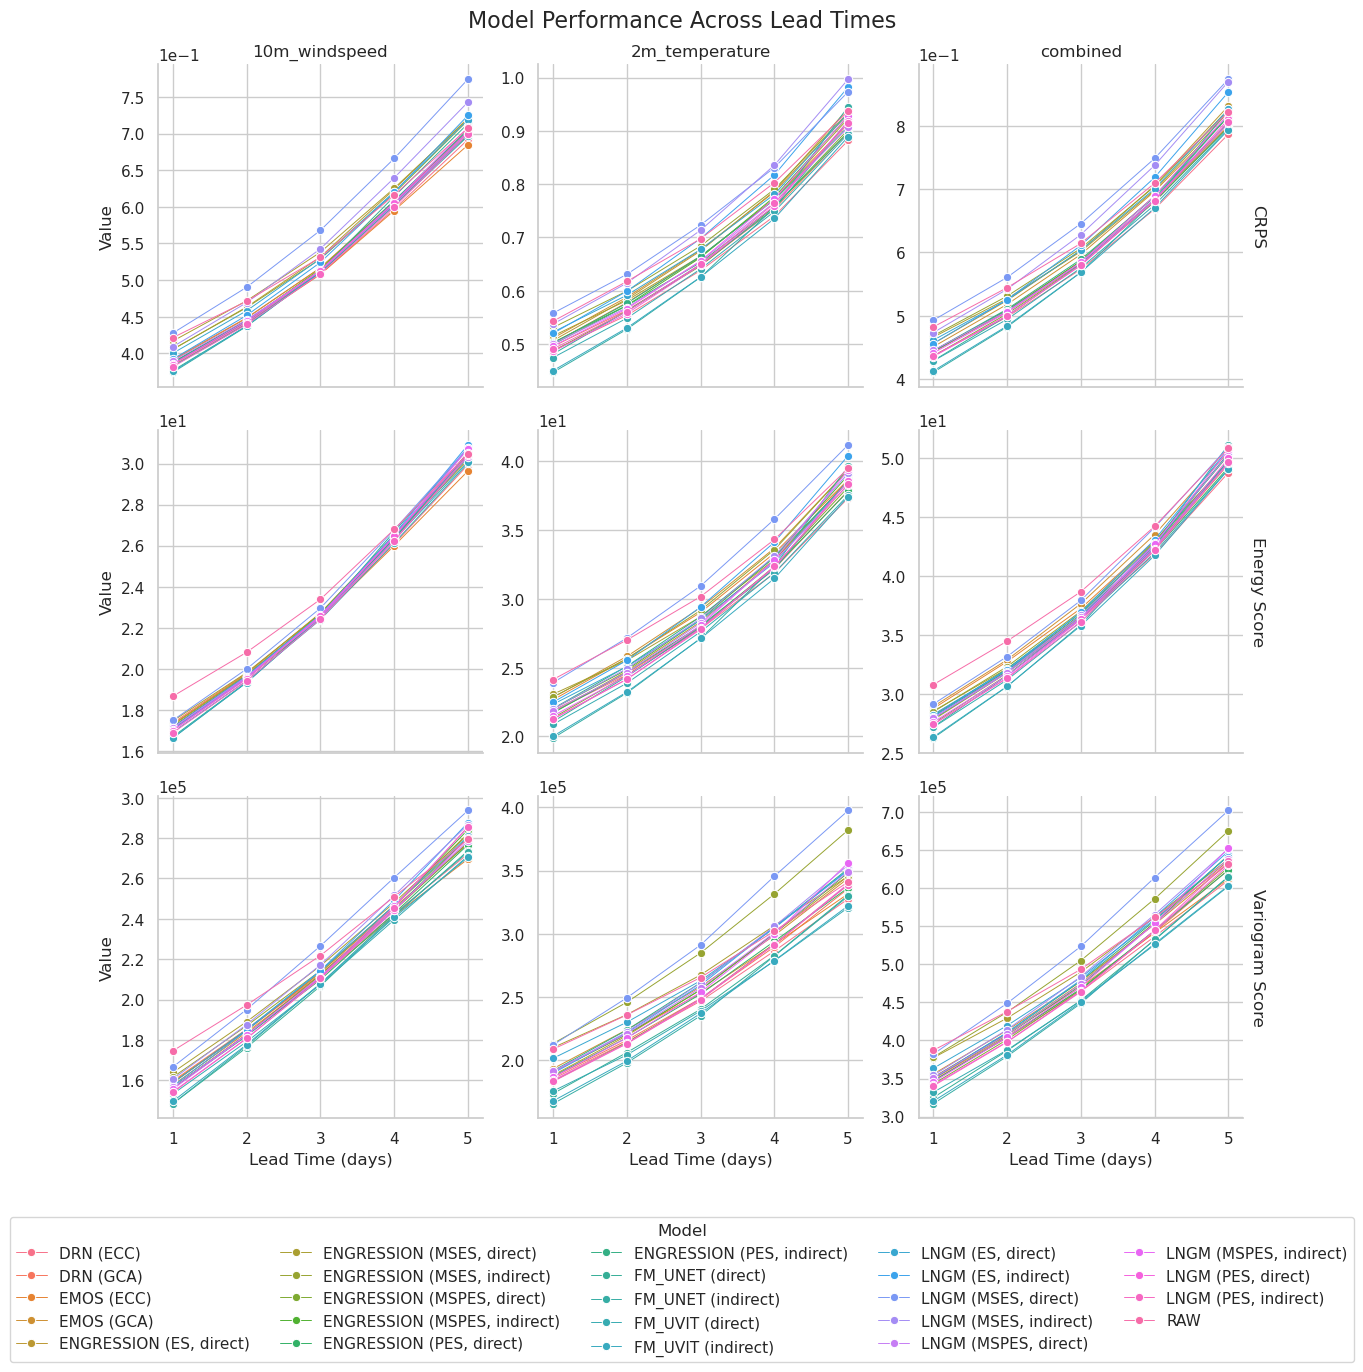

In [8]:
# Set seaborn style
sns.set_theme(style="whitegrid")
sns.set_palette("husl")  # Use tab10 colormap

# Convert to pandas for seaborn FacetGrid (works better with pandas)
df_pandas = df_plot.to_pandas()

# Get unique scores and variables to determine grid layout
n_scores = df_pandas["score"].nunique()
n_variables = df_pandas["variable"].nunique()

# Create FacetGrid with score as rows and variable as columns
g = sns.FacetGrid(
    df_pandas,
    col="variable",
    row="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Add legend below the plot with multiple columns
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(
    handles, labels, title="Model", bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=5
)

# Set labels
g.set_axis_labels("Lead Time (days)", "Value")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.subplots_adjust(top=0.95)
g.figure.suptitle("Model Performance Across Lead Times", fontsize=16)
plt.tight_layout()
plt.show()

## Normalize

In [9]:
from IPython.display import display

with pl.Config(tbl_rows=200):
    display(df_plot.filter(pl.col("model_method") == "RAW"))

run_id,dataset,model_name,method,pred_method,metric_name,value,timedelta,model_method,line_style,days,score,variable
str,str,str,str,str,str,f64,duration[μs],str,str,i64,str,str
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.421504,1d,"""RAW""","""indirect""",1,"""CRPS""","""10m_windspeed"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.471212,2d,"""RAW""","""indirect""",2,"""CRPS""","""10m_windspeed"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.531173,3d,"""RAW""","""indirect""",3,"""CRPS""","""10m_windspeed"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.616088,4d,"""RAW""","""indirect""",4,"""CRPS""","""10m_windspeed"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_10m_windspeed""",0.707274,5d,"""RAW""","""indirect""",5,"""CRPS""","""10m_windspeed"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_2m_temperature""",0.543003,1d,"""RAW""","""indirect""",1,"""CRPS""","""2m_temperature"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_2m_temperature""",0.61752,2d,"""RAW""","""indirect""",2,"""CRPS""","""2m_temperature"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_2m_temperature""",0.697524,3d,"""RAW""","""indirect""",3,"""CRPS""","""2m_temperature"""
"""utgo5npv""","""test""","""RAW""",null,null,"""CRPS_2m_temperature""",0.802818,4d,"""RAW""","""indirect""",4,"""CRPS""","""2m_temperature"""


In [10]:
df_plot = (
    df_plot.join(
        # Get the RAW values for each combination
        df_plot.filter(pl.col("model_method") == "RAW")
        .select(["timedelta", "score", "variable", "value"])
        .rename({"value": "raw_value"}),
        on=["timedelta", "score", "variable"],
        how="left",
    )
    .with_columns(
        # Calculate normalized value
        ((pl.col("raw_value") - pl.col("value")) / (pl.col("raw_value") - pl.lit(0.000))).alias(
            "normalized_value"
        )
    )
    .drop("raw_value")
)  # Remove the temporary raw_value column

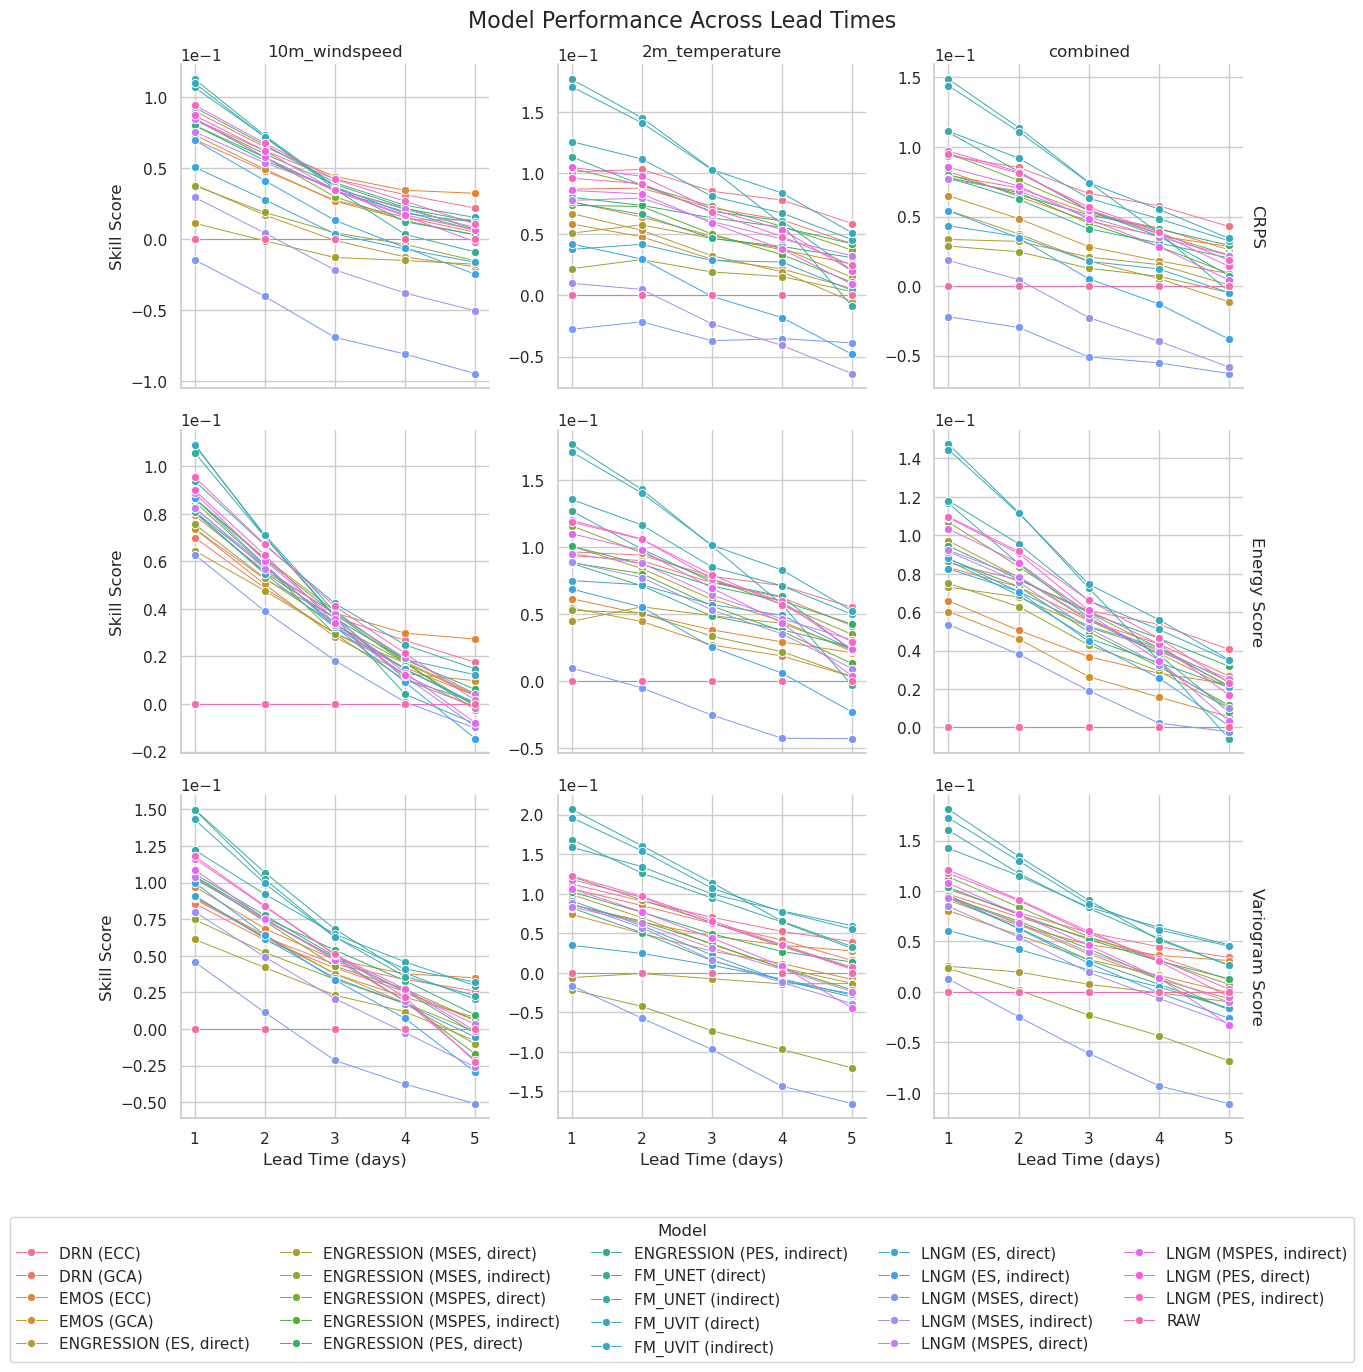

In [11]:
# Convert to pandas for seaborn FacetGrid (works better with pandas)
df_pandas = df_plot.to_pandas()

# Get unique scores and variables to determine grid layout
n_scores = df_pandas["score"].nunique()
n_variables = df_pandas["variable"].nunique()

# Create FacetGrid with score as rows and variable as columns
g = sns.FacetGrid(
    df_pandas,
    col="variable",
    row="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Plot lines for each model+method
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="normalized_value",
    hue="model_method",
    style="model_method",
    marker="o",
    linewidth=0.7,
    dashes=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Add legend below the plot with multiple columns
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(
    handles, labels, title="Model", bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=5
)

# Set labels
g.set_axis_labels("Lead Time (days)", "Skill Score")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

plt.subplots_adjust(top=0.95)
g.figure.suptitle("Model Performance Across Lead Times", fontsize=16)
plt.tight_layout()
plt.show()

## Plot each model class separately
- Use different markers for different Loss functions
- Use different linestyle for direct and indirect
- always keep RAW in every plot

In [12]:
model_typess = [
    ["EMOS", "DRN"],
    ["LNGM"],
    ["ENGRESSION"],
    ["FM_UNET", "FM_UVIT"],
]
# Color ranges for each model type
color_ranges = {
    "RAW": sns.color_palette("husl", n_colors=1),
    "EMOS": sns.color_palette("Oranges", n_colors=4),
    "DRN": sns.color_palette("cool", n_colors=8),
    "LNGM": sns.color_palette("Blues", n_colors=12),
    "ENGRESSION": sns.color_palette("Greens", n_colors=12),
    "FM": sns.color_palette("Purples", n_colors=8),
}

color_mapping = {
    "RAW": "black",
    "EMOS (ECC)": "#E65100",
    "EMOS (GCA)": "#FB8C00",
    "DRN (ECC)": "#4A148C",
    "DRN (GCA)": "#7E57C2",
    "LNGM (ES)": "#A5D6A7",
    "LNGM (PES)": "#4CAF50",
    "LNGM (MSES)": "#2E7D32",
    "LNGM (MSPES)": "#1B5E20",
    "ENGRESSION (ES)": "#BBDEFB",
    "ENGRESSION (PES)": "#42A5F5",
    "ENGRESSION (MSES)": "#1565C0",
    "ENGRESSION (MSPES)": "#0D47A1",
    "FM_UNET": "#00CED1",
    "FM_UVIT": "#F83E82",
}

FULL_HUE_ORDER = [
    "RAW",
    "EMOS (ECC)",
    "EMOS (GCA)",
    "DRN (ECC)",
    "DRN (GCA)",
    "LNGM (ES)",
    "LNGM (PES)",
    "LNGM (MSES)",
    "LNGM (MSPES)",
    "ENGRESSION (ES)",
    "ENGRESSION (PES)",
    "ENGRESSION (MSES)",
    "ENGRESSION (MSPES)",
    "FM_UNET",
    "FM_UVIT",
]

In [13]:
df_plot

run_id,dataset,model_name,method,pred_method,metric_name,value,timedelta,model_method,line_style,days,score,variable,normalized_value
str,str,str,str,str,str,f64,duration[μs],str,str,i64,str,str,f64
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.386051,1d,"""DRN (ECC)""","""indirect""",1,"""CRPS""","""10m_windspeed""",0.08411
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.441939,2d,"""DRN (ECC)""","""indirect""",2,"""CRPS""","""10m_windspeed""",0.062123
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.508784,3d,"""DRN (ECC)""","""indirect""",3,"""CRPS""","""10m_windspeed""",0.04215
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.596849,4d,"""DRN (ECC)""","""indirect""",4,"""CRPS""","""10m_windspeed""",0.031228
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.691915,5d,"""DRN (ECC)""","""indirect""",5,"""CRPS""","""10m_windspeed""",0.021716
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",386974.0625,1d,"""RAW""","""indirect""",1,"""Variogram Score""","""combined""",0.0
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",437904.4375,2d,"""RAW""","""indirect""",2,"""Variogram Score""","""combined""",0.0
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",493449.375,3d,"""RAW""","""indirect""",3,"""Variogram Score""","""combined""",0.0


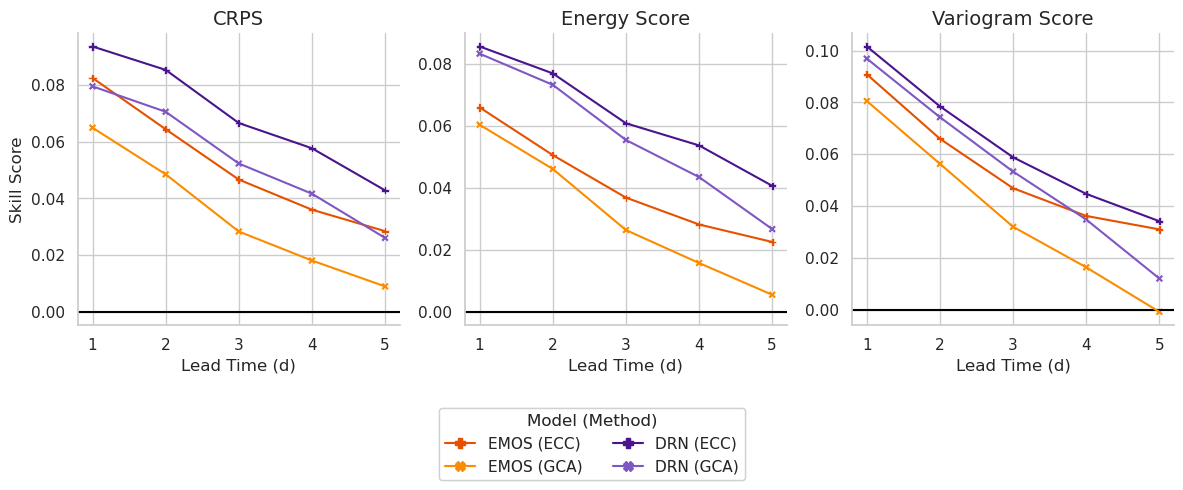

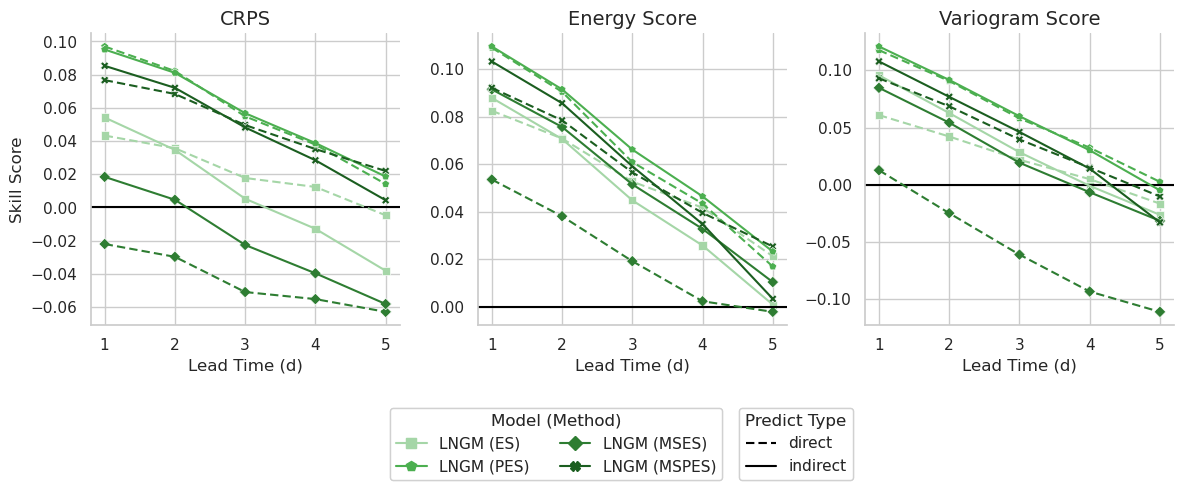

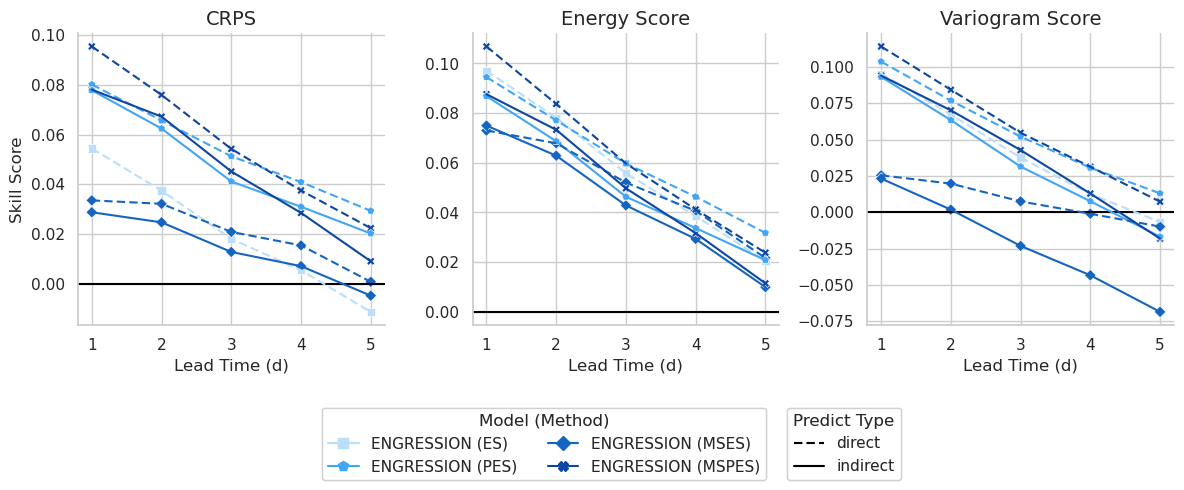

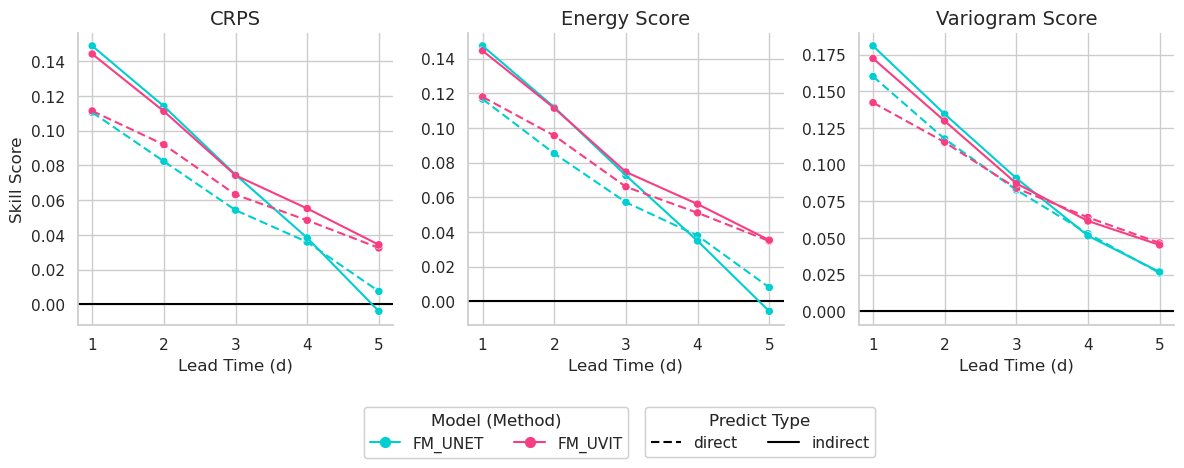

In [22]:
for model_types in model_typess:
    df_filtered = df_plot.filter(
        pl.col("model_name").is_in(model_types)
        & pl.col("metric_name").is_in(
            ["CRPS_combined", "EnergyScore_combined", "VariogramScore_combined"]
        )
    ).with_columns(
        pl.col("method").fill_null("null").alias("method_marker"),
        pl.when(pl.col("method").is_not_null())
        .then(pl.col("model_name") + " (" + pl.col("method") + ")")
        .otherwise(pl.col("model_name"))
        .alias("model_method_color"),
    )

    model_label = ", ".join([m for m in model_types if m != "RAW"]) or "RAW"

    # Sort color groups: RAW first, then alphabetical
    hue_order = (
        df_filtered.select(pl.col("model_method_color"))
        .unique()
        .sort(
            by=[
                pl.col("model_method_color") != "RAW",  # False (RAW) comes first
                pl.col("model_method_color"),
            ]
        )
        .to_series()
        .to_list()
    )
    hue_order = [h for h in FULL_HUE_ORDER if h in hue_order]  # Keep only those with defined colors

    # Build palette directly from simplified model/method color mapping
    color_mapping_model_method = {m: color_mapping.get(m, "black") for m in hue_order}

    method_order = ["null", "ECC", "GCA", "ES", "MSES", "PES", "MSPES"]
    method_markers = {
        "null": "o",
        "ECC": "P",
        "GCA": "X",
        "ES": "s",
        "MSES": "D",
        "PES": "p",
        "MSPES": "X",
    }

    present_method_set = set(
        df_filtered.select(pl.col("method_marker")).unique().to_series().to_list()
    )
    method_order_present = [m for m in method_order if m in present_method_set]

    # Marker per model/method entry for combined legend
    marker_pairs = df_filtered.select(["model_method_color", "method_marker"]).unique().to_dicts()
    model_method_to_marker = {
        pair["model_method_color"]: pair["method_marker"] for pair in marker_pairs
    }

    # Plot here
    g = sns.FacetGrid(
        df_filtered.to_pandas(),
        col="score",
        height=4,
        aspect=1,
        sharex=True,
        sharey=False,
        margin_titles=True,
    )

    # Lines: color by model+method, dashes by line_style
    g.map_dataframe(
        sns.lineplot,
        x="days",
        y="normalized_value",
        hue="model_method_color",
        hue_order=hue_order,
        palette=color_mapping_model_method,
        style="line_style",
        style_order=["indirect", "direct"],
        dashes={"indirect": "", "direct": (4, 2)},
        linewidth=1.5,
        legend=False,
    )

    # Markers: color by model+method, marker shape by method
    g.map_dataframe(
        sns.scatterplot,
        x="days",
        y="normalized_value",
        hue="model_method_color",
        hue_order=hue_order,
        palette=color_mapping_model_method,
        style="method_marker",
        style_order=method_order_present,
        markers=method_markers,
        s=35,
        legend=False,
    )

    # Format y-axes with scientific notation for large numbers
    for ax in g.axes.flat:
        # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
        ax.set_xlabel("Lead Time (d)", fontsize=12)
        ax.axhline(0, color="black", linewidth=1.5, zorder=1)
        ax.set_title(ax.get_title().replace("score = ", ""), fontsize=14)
        # Only set y-label on the leftmost plots
        if ax.get_ylabel() != "":
            ax.set_ylabel("Skill Score", fontsize=12)

    from matplotlib.lines import Line2D

    # Legend 1: Combined Model + Method (color + marker)
    combined_handles = [
        Line2D(
            [0],
            [0],
            color=color_mapping_model_method[m],
            marker=method_markers.get(model_method_to_marker.get(m, "null"), "o"),
            linestyle="-",
            linewidth=1.5,
            markersize=7,
            label=m,
        )
        for m in hue_order
    ]

    # Legend 2: Line style
    linestyle_handles = [
        Line2D([0], [0], color="black", linestyle=(0, (4, 2)), linewidth=1.5, label="direct"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=1.5, label="indirect"),
    ]
    if model_types == model_typess[0]:
        spacing1 = (0.5, -0.02)
        ncol1 = 2
    else:
        if model_types == model_typess[1]:
            spacing1 = (0.47, -0.02)
            ncol1 = 2
            spacing2 = (0.67, -0.02)
            ncol2 = 1
        elif model_types == model_typess[2]:
            spacing1 = (0.46, -0.02)
            ncol1 = 2
            spacing2 = (0.71, -0.02)
            ncol2 = 1
        else:
            spacing1 = (0.42, -0.02)
            ncol1 = 2
            spacing2 = (0.64, -0.02)
            ncol2 = 2

        linestyle_legend = g.figure.legend(
            linestyle_handles,
            ["direct", "indirect"],
            title="Predict Type",
            bbox_to_anchor=spacing2,
            loc="upper center",
            ncol=ncol2,
        )
        g.figure.add_artist(linestyle_legend)

    combined_legend = g.figure.legend(
        combined_handles,
        hue_order,
        title="Model (Method)",
        bbox_to_anchor=spacing1,
        loc="upper center",
        ncol=ncol1,
    )
    g.figure.add_artist(combined_legend)

    # g.figure.suptitle(f"{model_label} Model Performance Across Lead Times", fontsize=14, y=1.00)
    g.figure.tight_layout()
    g.figure.savefig(
        RESULTS_DIR
        / "results"
        / "wb2"
        / f"model_comparison_skill_{model_label.replace(', ', '_')}.pdf",
        bbox_inches="tight",
    )

## Only plot models with Standard loss FN

In [15]:
df_plot

run_id,dataset,model_name,method,pred_method,metric_name,value,timedelta,model_method,line_style,days,score,variable,normalized_value
str,str,str,str,str,str,f64,duration[μs],str,str,i64,str,str,f64
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.386051,1d,"""DRN (ECC)""","""indirect""",1,"""CRPS""","""10m_windspeed""",0.08411
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.441939,2d,"""DRN (ECC)""","""indirect""",2,"""CRPS""","""10m_windspeed""",0.062123
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.508784,3d,"""DRN (ECC)""","""indirect""",3,"""CRPS""","""10m_windspeed""",0.04215
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.596849,4d,"""DRN (ECC)""","""indirect""",4,"""CRPS""","""10m_windspeed""",0.031228
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.691915,5d,"""DRN (ECC)""","""indirect""",5,"""CRPS""","""10m_windspeed""",0.021716
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",386974.0625,1d,"""RAW""","""indirect""",1,"""Variogram Score""","""combined""",0.0
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",437904.4375,2d,"""RAW""","""indirect""",2,"""Variogram Score""","""combined""",0.0
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",493449.375,3d,"""RAW""","""indirect""",3,"""Variogram Score""","""combined""",0.0


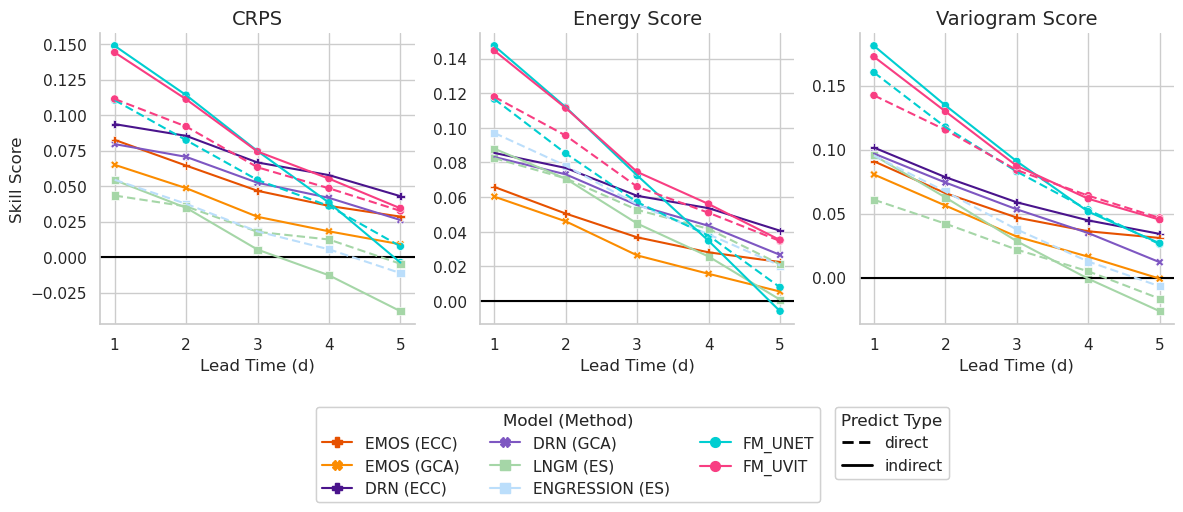

In [ ]:
df_filtered = df_plot.filter(
    (
        pl.col("model_name").is_in(["EMOS", "DRN", "FM_UNET", "FM_UVIT"])
        | (pl.col("model_name").is_in(["LNGM", "ENGRESSION"]) & pl.col("method").eq("ES"))
    )
    & pl.col("metric_name").is_in(
        ["CRPS_combined", "EnergyScore_combined", "VariogramScore_combined"]
    )
).with_columns(
    pl.col("method").fill_null("null").alias("method_marker"),
    pl.when(pl.col("method").is_not_null())
    .then(pl.col("model_name") + " (" + pl.col("method") + ")")
    .otherwise(pl.col("model_name"))
    .alias("model_method_color"),
)

model_label = ", ".join([m for m in model_types if m != "RAW"])

# Sort color groups: RAW first, then alphabetical
hue_order = (
    df_filtered.select(pl.col("model_method_color"))
    .unique()
    .sort(
        by=[
            pl.col("model_method_color"),
        ]
    )
    .to_series()
    .to_list()
)
hue_order = [h for h in FULL_HUE_ORDER if h in hue_order]  # Keep only those with defined colors

# Build palette directly from simplified model/method color mapping
color_mapping_model_method = {m: color_mapping.get(m, "black") for m in hue_order}

method_order = ["null", "ECC", "GCA", "ES", "MSES", "PES", "MSPES"]
method_markers = {
    "null": "o",
    "ECC": "P",
    "GCA": "X",
    "ES": "s",
    "MSES": "D",
    "PES": "p",
    "MSPES": "X",
}

present_method_set = set(df_filtered.select(pl.col("method_marker")).unique().to_series().to_list())
method_order_present = [m for m in method_order if m in present_method_set]

# Marker per model/method entry for combined legend
marker_pairs = df_filtered.select(["model_method_color", "method_marker"]).unique().to_dicts()
model_method_to_marker = {
    pair["model_method_color"]: pair["method_marker"] for pair in marker_pairs
}

# Plot here
g = sns.FacetGrid(
    df_filtered.to_pandas(),
    col="score",
    height=4,
    aspect=1,
    sharex=True,
    sharey=False,
    margin_titles=True,
)

# Lines: color by model+method, dashes by line_style
g.map_dataframe(
    sns.lineplot,
    x="days",
    y="normalized_value",
    hue="model_method_color",
    hue_order=hue_order,
    palette=color_mapping_model_method,
    style="line_style",
    style_order=["indirect", "direct"],
    dashes={"indirect": "", "direct": (4, 2)},
    linewidth=1.5,
    legend=False,
)

# Markers: color by model+method, marker shape by method
g.map_dataframe(
    sns.scatterplot,
    x="days",
    y="normalized_value",
    hue="model_method_color",
    hue_order=hue_order,
    palette=color_mapping_model_method,
    style="method_marker",
    style_order=method_order_present,
    markers=method_markers,
    s=35,
    legend=False,
)

# Format y-axes with scientific notation for large numbers
for ax in g.axes.flat:
    # ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlabel("Lead Time (d)", fontsize=12)
    ax.set_title(ax.get_title().replace("score = ", ""), fontsize=14)
    # Only set y-label on the leftmost plots
    if ax.get_ylabel() != "":
        ax.set_ylabel("Skill Score", fontsize=12)

# Legend 1: Combined Model + Method (color + marker)
combined_handles = [
    Line2D(
        [0],
        [0],
        color=color_mapping_model_method[m],
        marker=method_markers.get(model_method_to_marker.get(m, "null"), "o"),
        linestyle="-",
        linewidth=1.5,
        markersize=7,
        label=m,
    )
    for m in hue_order
]

# Legend 2: Line style
linestyle_handles = [
    Line2D([0], [0], color="black", linestyle=(0, (4, 2)), linewidth=2, label="direct"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="indirect"),
]

linestyle_legend = g.figure.legend(
    linestyle_handles,
    ["direct", "indirect"],
    title="Predict Type",
    bbox_to_anchor=(0.75, -0.02),
    loc="upper center",
    ncol=1,
)
g.figure.add_artist(linestyle_legend)

combined_legend = g.figure.legend(
    combined_handles,
    hue_order,
    title="Model (Method)",
    bbox_to_anchor=(0.48, -0.02),
    loc="upper center",
    ncol=3,
)
g.figure.add_artist(combined_legend)

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1.5, zorder=1)

# g.figure.suptitle(f"{model_label} Model Performance Across Lead Times", fontsize=14, y=1.00)
g.figure.tight_layout()
g.figure.savefig(
    RESULTS_DIR / "results" / "wb2" / "model_comparison_skill.pdf",
    bbox_inches="tight",
)

## LaTeX Table

In [17]:
full_res

run_id,dataset,model_name,method,pred_method,metric_name,value,timedelta,model_method,line_style,days,score,variable
str,str,str,str,str,str,f64,duration[μs],str,str,i64,str,str
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.386051,1d,"""DRN (ECC)""","""indirect""",1,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.441939,2d,"""DRN (ECC)""","""indirect""",2,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.508784,3d,"""DRN (ECC)""","""indirect""",3,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.596849,4d,"""DRN (ECC)""","""indirect""",4,"""CRPS""","""10m_windspeed"""
"""m5y9kwlh""","""test""","""DRN""","""ECC""",null,"""CRPS_10m_windspeed""",0.691915,5d,"""DRN (ECC)""","""indirect""",5,"""CRPS""","""10m_windspeed"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",386974.0625,1d,"""RAW""","""indirect""",1,"""Variogram Score""","""combined"""
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",437904.4375,2d,"""RAW""","""indirect""",2,"""Variogram Score""","""combined"""
"""utgo5npv""","""test""","""RAW""",null,null,"""VariogramScore_combined""",493449.375,3d,"""RAW""","""indirect""",3,"""Variogram Score""","""combined"""


In [18]:
MODEL_ORDER = pl.Enum(["RAW", "EMOS", "DRN", "LNGM", "ENGRESSION", "FM_UNET", "FM_UVIT"])
METHOD_ORDER = pl.Enum(["null", "ECC", "GCA", "ES", "MSES", "PES", "MSPES"])

table_df = (
    full_res.filter(pl.col("variable").eq("combined"))
    .select(
        pl.col("model_name"),
        pl.col("method"),
        pl.col("pred_method"),
        pl.col("timedelta"),
        pl.col("score"),
        pl.col("value"),
    )
    .group_by(pl.col("model_name"), pl.col("method"), pl.col("pred_method"), pl.col("score"))
    .agg(pl.col("value").mean().alias("mean_score"))
    .pivot("score", values="mean_score", index=["model_name", "method", "pred_method"])
    .with_columns(
        pl.when(pl.col("method").eq("ECC") | pl.col("method").eq("GCA"))
        .then(pl.col("model_name") + "+" + pl.col("method"))
        .otherwise(pl.col("model_name"))
        .replace({"ENGRESSION": "ENG"})
        .alias("model_method"),
        pl.col("method").replace({"ECC": None, "GCA": None}).alias("Loss Fn"),
    )
    .with_columns(pl.col("model_name").cast(MODEL_ORDER), pl.col("method").cast(METHOD_ORDER))
    .sort(["model_name", "method"])
    .select(
        pl.col("model_method").alias("Model"),
        pl.col("Loss Fn"),
        pl.col("pred_method").alias("Prediction Method"),
        pl.col("CRPS"),
        pl.col("Energy Score"),
        pl.col("Variogram Score"),
    )
)

In [19]:
print(table_df)

shape: (25, 6)
┌──────────┬─────────┬───────────────────┬──────────┬──────────────┬─────────────────┐
│ Model    ┆ Loss Fn ┆ Prediction Method ┆ CRPS     ┆ Energy Score ┆ Variogram Score │
│ ---      ┆ ---     ┆ ---               ┆ ---      ┆ ---          ┆ ---             │
│ str      ┆ str     ┆ str               ┆ f64      ┆ f64          ┆ f64             │
╞══════════╪═════════╪═══════════════════╪══════════╪══════════════╪═════════════════╡
│ RAW      ┆ null    ┆ null              ┆ 0.634519 ┆ 39.806179    ┆ 502366.5375     │
│ EMOS+ECC ┆ null    ┆ null              ┆ 0.60403  ┆ 38.289481    ┆ 476949.74375    │
│ EMOS+GCA ┆ null    ┆ null              ┆ 0.615451 ┆ 38.71848     ┆ 486312.6625     │
│ DRN+ECC  ┆ null    ┆ null              ┆ 0.592791 ┆ 37.392284    ┆ 472490.975      │
│ DRN+GCA  ┆ null    ┆ null              ┆ 0.602541 ┆ 37.70574     ┆ 477672.16875    │
│ …        ┆ …       ┆ …                 ┆ …        ┆ …            ┆ …               │
│ ENG      ┆ MSPES   ┆ direc

In [20]:
# Convert to LaTeX table with booktabs, bold best, underline second best
score_cols = ["CRPS", "Energy Score", "Variogram Score"]

# Find best and second best for each score column (lower is better)
best = {}
second_best = {}
for col in score_cols:
    sorted_vals = table_df[col].drop_nulls().sort().to_list()
    best[col] = sorted_vals[0]
    second_best[col] = sorted_vals[1] if len(sorted_vals) > 1 else None

# Build LaTeX rows
latex_lines = []
latex_lines.append(r"\begin{table}[ht]")
latex_lines.append(r"\centering")
latex_lines.append(r"\begin{tabular}{llc rrr}")
latex_lines.append(r"\toprule")
latex_lines.append(
    r"\textbf{Model} & \textbf{Loss Fn} & \textbf{Direct?} & \textbf{CRPS} & \textbf{Energy Score} & \textbf{Variogram Score} ($\times 10^5$) \\"
)
latex_lines.append(r"\midrule")

for row in table_df.iter_rows(named=True):
    cells = []
    # Model column
    model = row["Model"].replace("_", r"\_")
    cells.append(model)
    # Loss Fn column
    loss_fn = row["Loss Fn"] if row["Loss Fn"] is not None else "--"
    cells.append(loss_fn)
    # Prediction Method column
    pred_method = row["Prediction Method"]
    if pred_method == "direct":
        cells.append(r"\ding{51}")
    elif pred_method == "indirect":
        cells.append(r"\ding{55}")
    else:
        cells.append("--")
    # Score columns
    for col in score_cols:
        val = row[col]
        if col == "Variogram Score":
            formatted = f"{val / 1e5:.2f}"
        elif col == "Energy Score":
            formatted = f"{val:.2f}"
        else:
            formatted = f"{val:.4f}"

        if val == best[col]:
            formatted = r"\textbf{" + formatted + "}"
        elif val == second_best[col]:
            formatted = r"\underline{" + formatted + "}"
        cells.append(formatted)
    latex_lines.append(" & ".join(cells) + r" \\")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\caption{Model comparison of mean scores across lead times.}")
latex_lines.append(r"\label{tab:model_scores}")
latex_lines.append(r"\end{table}")

latex_str = "\n".join(latex_lines)
print(latex_str)

\begin{table}[ht]
\centering
\begin{tabular}{llc rrr}
\toprule
\textbf{Model} & \textbf{Loss Fn} & \textbf{Direct?} & \textbf{CRPS} & \textbf{Energy Score} & \textbf{Variogram Score} ($\times 10^5$) \\
\midrule
RAW & -- & -- & 0.6345 & 39.81 & 5.02 \\
EMOS+ECC & -- & -- & 0.6040 & 38.29 & 4.77 \\
EMOS+GCA & -- & -- & 0.6155 & 38.72 & 4.86 \\
DRN+ECC & -- & -- & \underline{0.5928} & 37.39 & 4.72 \\
DRN+GCA & -- & -- & 0.6025 & 37.71 & 4.78 \\
LNGM & ES & \ding{51} & 0.6233 & 37.82 & 4.93 \\
LNGM & ES & \ding{55} & 0.6330 & 38.20 & 4.90 \\
LNGM & MSES & \ding{55} & 0.6502 & 37.93 & 4.94 \\
LNGM & MSES & \ding{51} & 0.6643 & 39.07 & 5.34 \\
LNGM & PES & \ding{51} & 0.6018 & 37.48 & 4.76 \\
LNGM & PES & \ding{55} & 0.6010 & 37.34 & 4.76 \\
LNGM & MSPES & \ding{51} & 0.6050 & 37.65 & 4.85 \\
LNGM & MSPES & \ding{55} & 0.6078 & 37.78 & 4.85 \\
ENG & ES & \ding{55} & 0.7744 & 44.13 & 8.82 \\
ENG & ES & \ding{51} & 0.6241 & 37.69 & 4.85 \\
ENG & MSES & \ding{55} & 0.6273 & 38.22 & 5.16 \\
ENG 